In [ ]:
import torch as t
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

In [ ]:
# dataset

<Axes: >

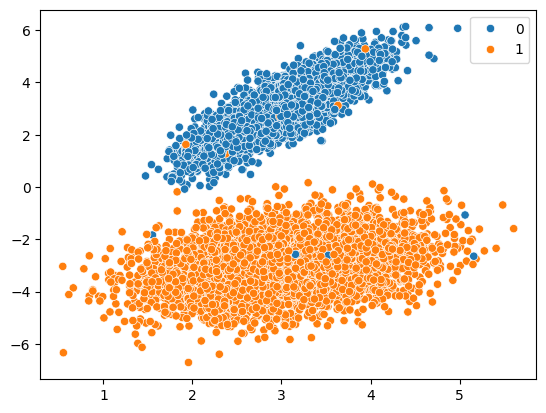

In [ ]:
fv,cv=make_classification(n_samples=10000,n_features=2,n_informative=2,n_redundant=0,random_state=1,n_repeated=0,n_classes=2,class_sep=3,n_clusters_per_class=1)
sns.scatterplot(x=fv[:,0],y=fv[:,1],hue=cv)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(fv,cv,test_size=0.2,stratify=cv)
x_trainf,x_cv,y_trainf,y_cv=train_test_split(x_train,y_train,test_size=0.2,stratify=y_train)

In [ ]:
"""
train=(x_traif,y_trainf)
cv=(x_cv,y_cv)
test=(x_test,y_test)"""

'\ntrain=(x_traif,y_trainf)\ncv=(x_cv,y_cv)\ntest=(x_test,y_test)'

In [ ]:
from sklearn.preprocessing import StandardScaler
st = StandardScaler()

In [ ]:
x_trains=st.fit_transform(x_trainf)
x_cvs=st.transform(x_cv)
x_tests=st.transform(x_test)

In [ ]:
x_trains=t.from_numpy(x_trains).to(dtype=t.float32)
y_train=t.from_numpy(y_trainf).to(dtype=t.float32)

x_cvs=t.from_numpy(x_cvs).to(dtype=t.float32)
y_cv=t.from_numpy(y_cv).to(dtype=t.float32)

x_tests=t.from_numpy(x_tests).to(dtype=t.float32)
y_test=t.from_numpy(y_test).to(dtype=t.float32)

In [ ]:
class BinarClass(t.nn.Module):
  def __init__(self,n_features):
    super().__init__()

    self.ann=t.nn.Sequential(
        t.nn.Linear(n_features,6),
        t.nn.Sigmoid(),
        t.nn.Linear(6,4),
        t.nn.Sigmoid(),
        t.nn.Linear(4,3),
        t.nn.Sigmoid(),
        t.nn.Linear(3,1),

    )

  def forward(self,data):
    return self.ann(data)

In [ ]:
model=BinarClass(2)


In [ ]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.6604,  0.6305],
         [ 0.5348, -0.3572],
         [ 0.0462,  0.4504],
         [ 0.0171, -0.4277],
         [-0.2552,  0.3607],
         [-0.0351,  0.5143]], requires_grad=True),
 Parameter containing:
 tensor([-0.5875, -0.0726, -0.5257, -0.5675, -0.3630, -0.1425],
        requires_grad=True),
 Parameter containing:
 tensor([[ 0.0680, -0.2538, -0.2288,  0.0966, -0.2321,  0.3902],
         [-0.3091, -0.3413,  0.0274, -0.0712,  0.2765, -0.2388],
         [ 0.1279, -0.3637,  0.0938, -0.4064,  0.1656, -0.0981],
         [ 0.0236, -0.2435,  0.1417, -0.0611, -0.0197,  0.2492]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.1683,  0.3015,  0.1110, -0.1458], requires_grad=True),
 Parameter containing:
 tensor([[-0.0457,  0.4769, -0.0116, -0.2449],
         [-0.1573, -0.0623, -0.2252,  0.0749],
         [-0.2693, -0.1083,  0.0245, -0.2898]], requires_grad=True),
 Parameter containing:
 tensor([-0.4860, -0.3898,  0.4233], requires_grad=Tr

In [ ]:
model=BinarClass(2)

# define the loss

loss=t.nn.BCEWithLogitsLoss()

# define the optimiser
opt=t.optim.SGD(model.parameters(),lr=0.9)

epochs=2000
sigmoid=t.nn.Sigmoid()

train_loss_data=[]
cv_loss_data=[]

train_acc_data=[]
cv_acc_data=[]
for iter in range(epochs):
  model.train()

  predi_t=model(x_trains)

  prob_output_t=sigmoid(predi_t)

  pr_labeltrain=[]
  for prob in prob_output_t.squeeze():
    if prob>=0.5:
      pr_labeltrain.append(1)
    else:
      pr_labeltrain.append(0)

  train_acc_data.append(accuracy_score(y_train,pr_labeltrain))

  train_loss=loss(predi_t.squeeze(),y_train)

  opt.zero_grad()

  train_loss.backward()

  opt.step()

  model.eval()

  with t.no_grad():
    predi_cv=model(x_cvs)
    prob_output_cv=sigmoid(predi_cv)

    pr_labelcv=[]
    for prob in prob_output_cv.squeeze():
      if prob>=0.5:
        pr_labelcv.append(1)
      else:
        pr_labelcv.append(0)

    cv_acc_data.append(accuracy_score(y_cv,pr_labelcv))

    cv_loss=loss(predi_cv.squeeze(),y_cv)

  train_loss_data.append(train_loss.detach().numpy())
  cv_loss_data.append(cv_loss.numpy())

  print("epochs :{}, train_loss :{}, cv_loss :{} // train_acc :{}, cv_acc :{}".format(iter+1,train_loss,cv_loss,accuracy_score(y_train,pr_labeltrain),accuracy_score(y_cv,pr_labelcv)))



epochs :1, train_loss :0.7225455641746521, cv_loss :0.7040039896965027 // train_acc :0.5003125, cv_acc :0.5
epochs :2, train_loss :0.7039095163345337, cv_loss :0.6971800923347473 // train_acc :0.5003125, cv_acc :0.5
epochs :3, train_loss :0.6971211433410645, cv_loss :0.6947452425956726 // train_acc :0.5003125, cv_acc :0.5
epochs :4, train_loss :0.6947073340415955, cv_loss :0.6938825249671936 // train_acc :0.5003125, cv_acc :0.5
epochs :5, train_loss :0.6938571333885193, cv_loss :0.6935763359069824 // train_acc :0.5003125, cv_acc :0.5
epochs :6, train_loss :0.6935584545135498, cv_loss :0.6934665441513062 // train_acc :0.5003125, cv_acc :0.5
epochs :7, train_loss :0.6934530138969421, cv_loss :0.6934261918067932 // train_acc :0.5003125, cv_acc :0.5
epochs :8, train_loss :0.6934152841567993, cv_loss :0.6934106349945068 // train_acc :0.5003125, cv_acc :0.5
epochs :9, train_loss :0.6934011578559875, cv_loss :0.6934038400650024 // train_acc :0.5003125, cv_acc :0.5
epochs :10, train_loss :0.69

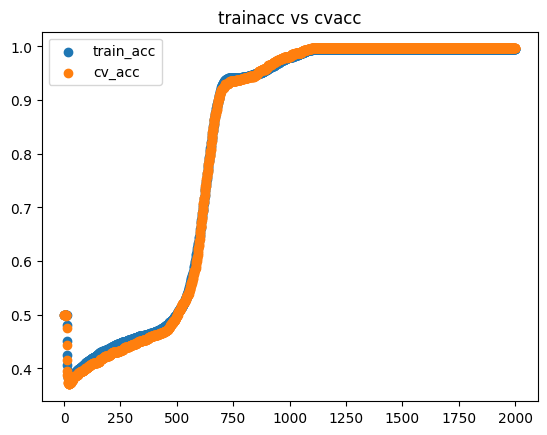

In [ ]:
plt.scatter(range(1,2000+1),train_acc_data,label="train_acc")
plt.scatter(range(1,2000+1),cv_acc_data,label="cv_acc")
plt.title("trainacc vs cvacc")
plt.legend()
plt.show()

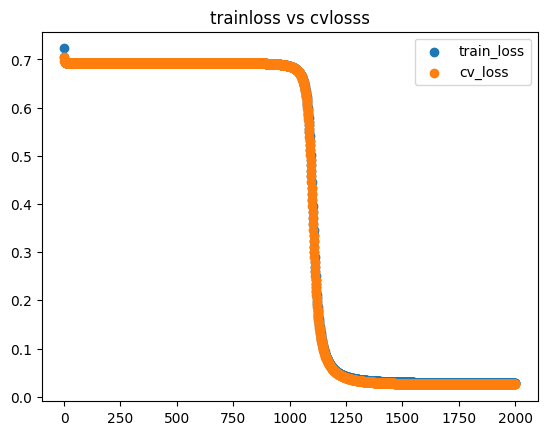

In [ ]:
plt.scatter(range(1,2000+1),train_loss_data,label="train_loss")
plt.scatter(range(1,2000+1),cv_loss_data,label="cv_loss")
plt.title("trainloss vs cvlosss")
plt.legend()
plt.show()

In [ ]:
model.paramete

BinarClass(
  (ann): Sequential(
    (0): Linear(in_features=2, out_features=6, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=6, out_features=4, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=4, out_features=3, bias=True)
    (5): Sigmoid()
    (6): Linear(in_features=3, out_features=1, bias=True)
  )
)

In [ ]:
with t.no_grad():
  predi_test=model(x_tests)

In [ ]:
sigmoid=t.nn.Sigmoid()
prob_output=sigmoid(predi_test)

In [ ]:
pr_labeltest=[]
for prob in prob_output.squeeze():
  if prob>=0.5:
     pr_labeltest.append(1)
  else:
    pr_labeltest.append(0)

In [ ]:
pr_labeltest

[1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,


In [ ]:
y_test

tensor([1., 0., 1.,  ..., 1., 1., 1.])

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,precision_score,recall_score,f1_score,classification_report,log_loss


In [ ]:
accuracy_score(y_test,pr_labeltest)

0.9965

In [ ]:
confusion_matrix(y_test,pr_labeltest)

array([[997,   2],
       [  5, 996]])

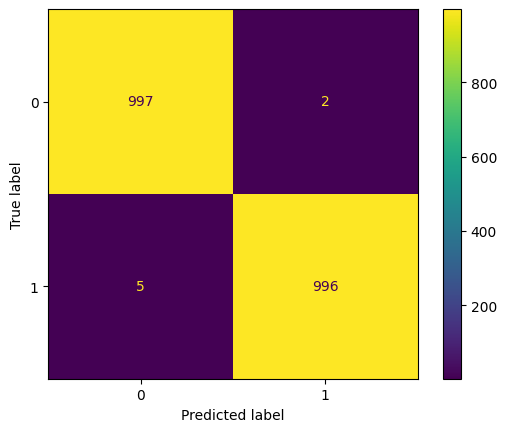

In [ ]:
cmd=ConfusionMatrixDisplay(confusion_matrix(y_test,pr_labeltest))
cmd.plot()

In [ ]:
tn,fp,fn,tp=confusion_matrix(y_test,pr_labeltest).ravel()

In [ ]:
tn/(tn+fp)


np.float64(0.997997997997998)

In [ ]:
precision_score(y_test,pr_labeltest,pos_label=0)

0.9950099800399201

In [ ]:
precision_score(y_test,pr_labeltest,pos_label=1)

0.9979959919839679

In [ ]:
recall_score(y_test,pr_labeltest,pos_label=0)

0.997997997997998

In [ ]:
recall_score(y_test,pr_labeltest,pos_label=1)

0.995004995004995

In [ ]:
f1_score(y_test,pr_labeltest,pos_label=1)

0.9964982491245623

In [ ]:
f1_score(y_test,pr_labeltest,pos_label=0)

0.9965017491254373

In [ ]:
print(classification_report(y_test,pr_labeltest))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       999
         1.0       1.00      1.00      1.00      1001

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
log_loss(y_test,pr_labeltest)

0.12615278686191028